In [7]:
import numpy as np
import xarray as xr
import rioxarray as rxr
from rioxarray.merge import merge_arrays
from scipy import stats
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates

## Overviev

In [10]:
import netCDF4 as nc

ds = nc.Dataset('/projekt1/ag_maahn/data_obs_nobackup/modis/MCD06COSP_D3/Amazon_cropped/2002/MCD06COSP_D3_MODIS.A2002354.062.2022125082709.nc')
print(ds.groups.keys())

dict_keys(['Cloud_Top_Pressure', 'Cloud_Mask_Fraction', 'Cloud_Mask_Fraction_Low', 'Cloud_Mask_Fraction_Mid', 'Cloud_Mask_Fraction_High', 'Cloud_Optical_Thickness_Liquid', 'Cloud_Optical_Thickness_Ice', 'Cloud_Optical_Thickness_Total', 'Cloud_Optical_Thickness_PCL_Liquid', 'Cloud_Optical_Thickness_PCL_Ice', 'Cloud_Optical_Thickness_PCL_Total', 'Cloud_Optical_Thickness_Log10_Liquid', 'Cloud_Optical_Thickness_Log10_Ice', 'Cloud_Optical_Thickness_Log10_Total', 'Cloud_Particle_Size_Liquid', 'Cloud_Particle_Size_Ice', 'Cloud_Particle_Size_PCL_Liquid', 'Cloud_Particle_Size_PCL_Ice', 'Cloud_Water_Path_Liquid', 'Cloud_Water_Path_Ice', 'Cloud_Water_Path_PCL_Liquid', 'Cloud_Water_Path_PCL_Ice'])


In [11]:
ds = nc.Dataset('/projekt1/ag_maahn/data_obs_nobackup/modis/MCD06COSP_D3/2002/MCD06COSP_D3_MODIS.A2002361.062.2022125081935.nc')
print(ds.groups.keys())

dict_keys(['Solar_Zenith', 'Solar_Azimuth', 'Sensor_Zenith', 'Sensor_Azimuth', 'Cloud_Top_Pressure', 'Cloud_Mask_Fraction', 'Cloud_Mask_Fraction_Low', 'Cloud_Mask_Fraction_Mid', 'Cloud_Mask_Fraction_High', 'Cloud_Optical_Thickness_Liquid', 'Cloud_Optical_Thickness_Ice', 'Cloud_Optical_Thickness_Total', 'Cloud_Optical_Thickness_PCL_Liquid', 'Cloud_Optical_Thickness_PCL_Ice', 'Cloud_Optical_Thickness_PCL_Total', 'Cloud_Optical_Thickness_Log10_Liquid', 'Cloud_Optical_Thickness_Log10_Ice', 'Cloud_Optical_Thickness_Log10_Total', 'Cloud_Particle_Size_Liquid', 'Cloud_Particle_Size_Ice', 'Cloud_Particle_Size_PCL_Liquid', 'Cloud_Particle_Size_PCL_Ice', 'Cloud_Water_Path_Liquid', 'Cloud_Water_Path_Ice', 'Cloud_Water_Path_PCL_Liquid', 'Cloud_Water_Path_PCL_Ice', 'Cloud_Retrieval_Fraction_Liquid', 'Cloud_Retrieval_Fraction_Ice', 'Cloud_Retrieval_Fraction_Total', 'Cloud_Retrieval_Fraction_PCL_Liquid', 'Cloud_Retrieval_Fraction_PCL_Ice', 'Cloud_Retrieval_Fraction_PCL_Total'])


In [4]:
for group_name in ['Cloud_Mask_Fraction', 'Cloud_Optical_Thickness_Total']:
    group = ds.groups[group_name]
    print(f"\n{group_name}: {list(group.variables.keys())}")


Cloud_Mask_Fraction: ['Mean', 'Standard_Deviation', 'Sum', 'Pixel_Counts', 'Sum_Squares']

Cloud_Optical_Thickness_Total: ['Mean', 'Standard_Deviation', 'Sum', 'Pixel_Counts', 'Sum_Squares', 'JHisto_vs_Cloud_Top_Pressure']


In [16]:
ds = nc.Dataset('/projekt1/ag_maahn/data_obs_nobackup/modis/MCD06COSP_D3/2002/MCD06COSP_D3_MODIS.A2002361.062.2022125081935.nc')

In [17]:
ds

<class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    YAML_config: grid_settings:
  gridsize: 1
  projection: conformal
  lat_in: Latitude
  lon_in: Longitude
  lat_out: Latitude
  lon_out: Longitude
  fill_value: -999

variable_settings:

  - name_in: Solar_Zenith
    name_out: Solar_Zenith
    attributes: 
    - name: long_name
      value: Solar Zenith Angle (Cell to Sun) for Daytime Scenes
    - name: units
      value: degrees
    - name: _FillValue
      value: -999.0
    - name: valid_min
      value: 0.0
    - name: valid_max
      value: 180.0
    - name: scale_factor
      value: 1.0
    - name: add_offset
      value: 0.0
    masks:
    - Mask_Day

  - name_in: Solar_Azimuth
    name_out: Solar_Azimuth
    attributes: 
    - name: long_name
      value: Solar Azimuth Angle (Cell to Sun) for Daytime Scenes
    - name: units
      value: degrees
    - name: _FillValue
      value: -999.0
    - name: valid_min
      value: -180.0
    - name: valid_max

## ab hier mit ENSO experimentiert

In [8]:
# Einlesen
df = pd.read_csv(
    "meiv2.data",
    sep=r'\s+',
    header=0,
    skipfooter=4,
    engine='python',
    na_values=[-999, -999.0]
)

df.columns = ["year", "DJ", "JF", "FM", "MA", "AM", "MJ", "JJ", "JA", "AS", "SO", "ON", "ND"]

# Zweiter Monat pro Saison → Monatsnummer
season_to_month = {
    "DJ": 1, "JF": 2, "FM": 3, "MA": 4, "AM": 5, "MJ": 6,
    "JJ": 7, "JA": 8, "AS": 9, "SO": 10, "ON": 11, "ND": 12
}

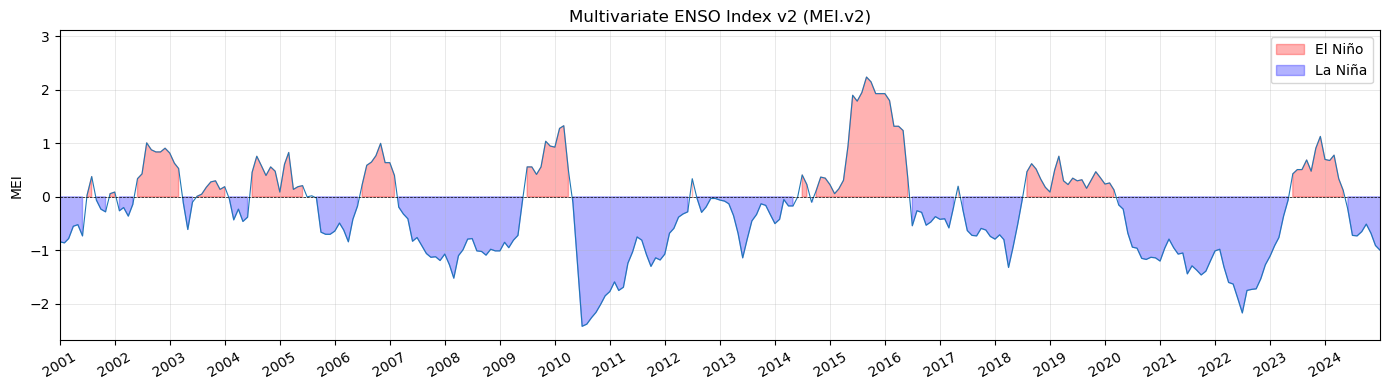

In [9]:
# Wide → Long, dann Datum bauen
df_long = df.melt(id_vars="year", var_name="season", value_name="mei")
df_long["month"] = df_long["season"].map(season_to_month)
df_long["date"] = pd.to_datetime(df_long[["year", "month"]].assign(day=1))
df_long = df_long.dropna(subset=["mei"]).sort_values("date")

# Plotten
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_long["date"], df_long["mei"], linewidth=0.8)
ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
ax.fill_between(df_long["date"], df_long["mei"], 0,
                where=df_long["mei"] > 0, color="red", alpha=0.3, label="El Niño")
ax.fill_between(df_long["date"], df_long["mei"], 0,
                where=df_long["mei"] < 0, color="blue", alpha=0.3, label="La Niña")
ax.set_xlim(pd.Timestamp("2001-01-01"), pd.Timestamp("2024-12-31"))
ax.set_title("Multivariate ENSO Index v2 (MEI.v2)")

'''
start_date = pd.Timestamp("2003-01-01")
end_date = pd.Timestamp("2023-12-01")

start_val = df_long.loc[df_long["date"] == start_date, "mei"].iloc[0]
end_val = df_long.loc[df_long["date"] == end_date, "mei"].iloc[0]

ax.plot([start_date, end_date], [start_val, end_val],
        color="green", linewidth=1.5, linestyle="-", label="Trend 2003–2023")
'''
ax.set_ylabel("MEI")
ax.legend()
ax.grid(True, linewidth=0.4, alpha=0.5)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=30)
plt.tight_layout()
#plt.savefig("mei_timeseries.png", dpi=150)
plt.show()

00,LA--> 2002 bis 2024 (GL)

00,El --> 2002 bis 2023
EL,EL --> 2003 bis 2023
EL,LA --> 2003 bis 2024
LA,EL --> 2006 bis 2023
La,La --> 2006 bis 2024

